# Projet Audio: Reconnaissance des Émotions

Ce projet a pour but de structurer, prétraiter et analyser des données audios provenant de 4 datasets différents (RAVDESS, CREMA-D, SAVEE, TESS).

In [1]:
import torch
import tensorflow as tf
import os

# Vérifier GPU
print("🔥 PyTorch GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Non disponible")
print("🔥 TensorFlow GPU :", tf.config.list_physical_devices('GPU'))

# Voir les datasets disponibles
print("\n📁 Datasets disponibles :")
for dataset in os.listdir('/kaggle/input'):
    print(f"   → {dataset}")

2026-05-05 19:58:10.126677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778011090.369458      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778011090.446594      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778011091.003538      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778011091.003596      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778011091.003602      57 computation_placer.cc:177] computation placer alr

🔥 PyTorch GPU : Tesla P100-PCIE-16GB
🔥 TensorFlow GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

📁 Datasets disponibles :
   → datasets


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [2]:
import os

base = '/kaggle/input/datasets'
for item in os.listdir(base):
    path = os.path.join(base, item)
    n_files = sum([len(f) for _, _, f in os.walk(path)])
    print(f"📁 {item} → {n_files} fichiers")

📁 uwrfkaggler → 2880 fichiers
📁 ejlok1 → 13042 fichiers
📁 barelydedicated → 962 fichiers


In [3]:
import os

base = '/kaggle/input/datasets'

for author in os.listdir(base):
    author_path = os.path.join(base, author)
    print(f"\n👤 {author} :")
    for dataset in os.listdir(author_path):
        dataset_path = os.path.join(author_path, dataset)
        n_files = sum([len(f) for _, _, f in os.walk(dataset_path)])
        print(f"   📁 {dataset} → {n_files} fichiers")


👤 uwrfkaggler :
   📁 ravdess-emotional-speech-audio → 2880 fichiers

👤 ejlok1 :
   📁 toronto-emotional-speech-set-tess → 5600 fichiers
   📁 cremad → 7442 fichiers

👤 barelydedicated :
   📁 savee-database → 962 fichiers


In [4]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## 1. Mappage et Définition des Sentiments

- **0**: Neutre, **1**: Joie, **2**: Tristesse, **3**: Colère, **4**: Peur, **5**: Dégoût, **6**: Surprise, **7**: Calm

## 2. Extraction et Consolidation des Datasets

Nous extrayons le chemin relatif, absolu et le sentiment pour chaque fichier audio.

In [5]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# ==========================================
# CHEMINS KAGGLE
# ==========================================
BASE = '/kaggle/input/datasets'

RAVDESS_PATH = f'{BASE}/uwrfkaggler/ravdess-emotional-speech-audio'
TESS_PATH    = f'{BASE}/ejlok1/toronto-emotional-speech-set-tess'
CREMAD_PATH  = f'{BASE}/ejlok1/cremad/AudioWAV'
SAVEE_PATH   = f'{BASE}/barelydedicated/savee-database'

# Dossier de sauvegarde (stockage local Kaggle — 20Go disponibles)
SAVE_DIR = '/kaggle/working/features'
os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Chemins configurés :")
print(f"   RAVDESS  : {RAVDESS_PATH}")
print(f"   TESS     : {TESS_PATH}")
print(f"   CREMA-D  : {CREMAD_PATH}")
print(f"   SAVEE    : {SAVEE_PATH}")
print(f"   Features : {SAVE_DIR}")

# ==========================================
# MAPPINGS DES ÉMOTIONS
# ==========================================
emotion_map_str_to_int = {
    'Neutral': 0, 'Happy': 1, 'Sad': 2,
    'Angry': 3, 'Fear': 4, 'Disgust': 5, 'Surprise': 6
}

ravdess_map = {
    '01':'Neutral', '03':'Happy', '04':'Sad',
    '05':'Angry',   '06':'Fear',  '07':'Disgust', '08':'Surprise'
}  # '02' Calm → ignoré

crema_map = {
    'NEU':'Neutral', 'HAP':'Happy', 'SAD':'Sad',
    'ANG':'Angry',   'FEA':'Fear',  'DIS':'Disgust'
}

savee_map = {
    'n':'Neutral', 'h':'Happy', 'sa':'Sad',
    'a':'Angry',   'f':'Fear',  'd':'Disgust', 'su':'Surprise'
}

tess_map = {
    'neutral':'Neutral', 'happy':'Happy', 'sad':'Sad',
    'angry':'Angry',     'fear':'Fear',   'disgust':'Disgust',
    'ps':'Surprise',     'pleasant_surprise':'Surprise'
}

# ==========================================
# FONCTIONS DE PARSING
# ==========================================
def parse_ravdess(fp):
    parts = os.path.basename(fp).split('-')
    if len(parts) >= 3 and parts[2] in ravdess_map:
        emo = ravdess_map[parts[2]]
        return {'Chemin_Absolu': fp, 'Dataset': 'RAVDESS',
                'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

def parse_cremad(fp):
    parts = os.path.basename(fp).split('_')
    if len(parts) >= 3 and parts[2] in crema_map:
        emo = crema_map[parts[2]]
        return {'Chemin_Absolu': fp, 'Dataset': 'CREMA-D',
                'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

def parse_tess(fp):
    fn_lower = fp.lower()
    for key, emo in tess_map.items():
        if key in fn_lower:
            return {'Chemin_Absolu': fp, 'Dataset': 'TESS',
                    'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

def parse_savee(fp):
    parts = os.path.basename(fp).split('_')
    if len(parts) == 2:
        emo_code = ''.join([c for c in parts[1] if not c.isdigit()]).replace('.wav','')
        if emo_code in savee_map:
            emo = savee_map[emo_code]
            return {'Chemin_Absolu': fp, 'Dataset': 'SAVEE',
                    'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

# ==========================================
# INDEXATION DES FICHIERS
# ==========================================
tasks = [
    (parse_ravdess, [os.path.join(r,f) for r,_,fs in os.walk(RAVDESS_PATH) for f in fs if f.endswith('.wav')], 'RAVDESS'),
    (parse_cremad,  [os.path.join(r,f) for r,_,fs in os.walk(CREMAD_PATH)  for f in fs if f.endswith('.wav')], 'CREMA-D'),
    (parse_tess,    [os.path.join(r,f) for r,_,fs in os.walk(TESS_PATH)    for f in fs if f.endswith('.wav')], 'TESS'),
    (parse_savee,   [os.path.join(r,f) for r,_,fs in os.walk(SAVEE_PATH)   for f in fs if f.endswith('.wav')], 'SAVEE'),
]

all_data = []
for parse_func, files, name in tasks:
    if not files:
        print(f"⚠️ Aucun fichier trouvé pour {name}")
        continue
    with ThreadPoolExecutor() as executor:
        results = list(tqdm(executor.map(parse_func, files), total=len(files), desc=f"Indexation {name}"))
    all_data.extend([r for r in results if r is not None])

df_audio = pd.DataFrame(all_data).drop_duplicates(subset='Chemin_Absolu')
df_audio = df_audio[df_audio['Sentiment'] != 'Calm']

print(f"\n✅ Dataset prêt : {len(df_audio)} fichiers")
print(df_audio['Sentiment'].value_counts().to_string())

✅ Chemins configurés :
   RAVDESS  : /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
   TESS     : /kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess
   CREMA-D  : /kaggle/input/datasets/ejlok1/cremad/AudioWAV
   SAVEE    : /kaggle/input/datasets/barelydedicated/savee-database
   Features : /kaggle/working/features


Indexation SAVEE: 100%|██████████| 960/960 [00:00<00:00, 410075.55it/s]


✅ Dataset prêt : 15538 fichiers
Sentiment
Disgust     2455
Sad         2455
Fear        2455
Happy       2455
Angry       2455
Neutral     2079
Surprise    1184


## 3. Analyse Exploratoire et Visualisations et Visualisation d'Audios et Spectrogrammes de Mel

Distribution des fichiers au travers des différents datasets et sentiments.

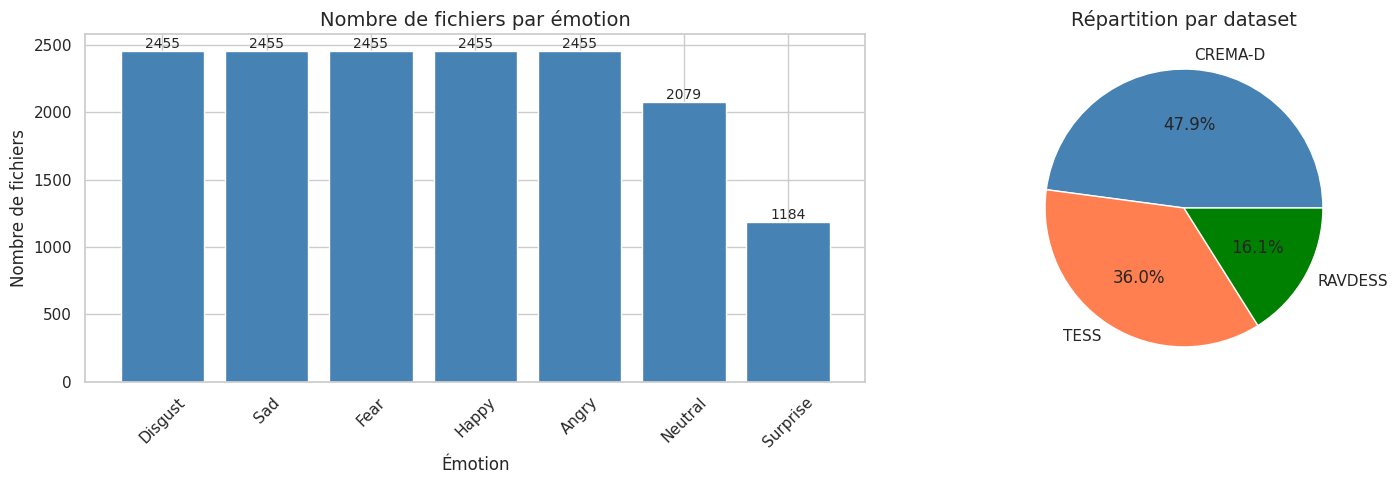

📊 Résumé :
   Total fichiers    : 15538
   Nombre d'émotions : 7
   Datasets          : ['RAVDESS', 'CREMA-D', 'TESS']


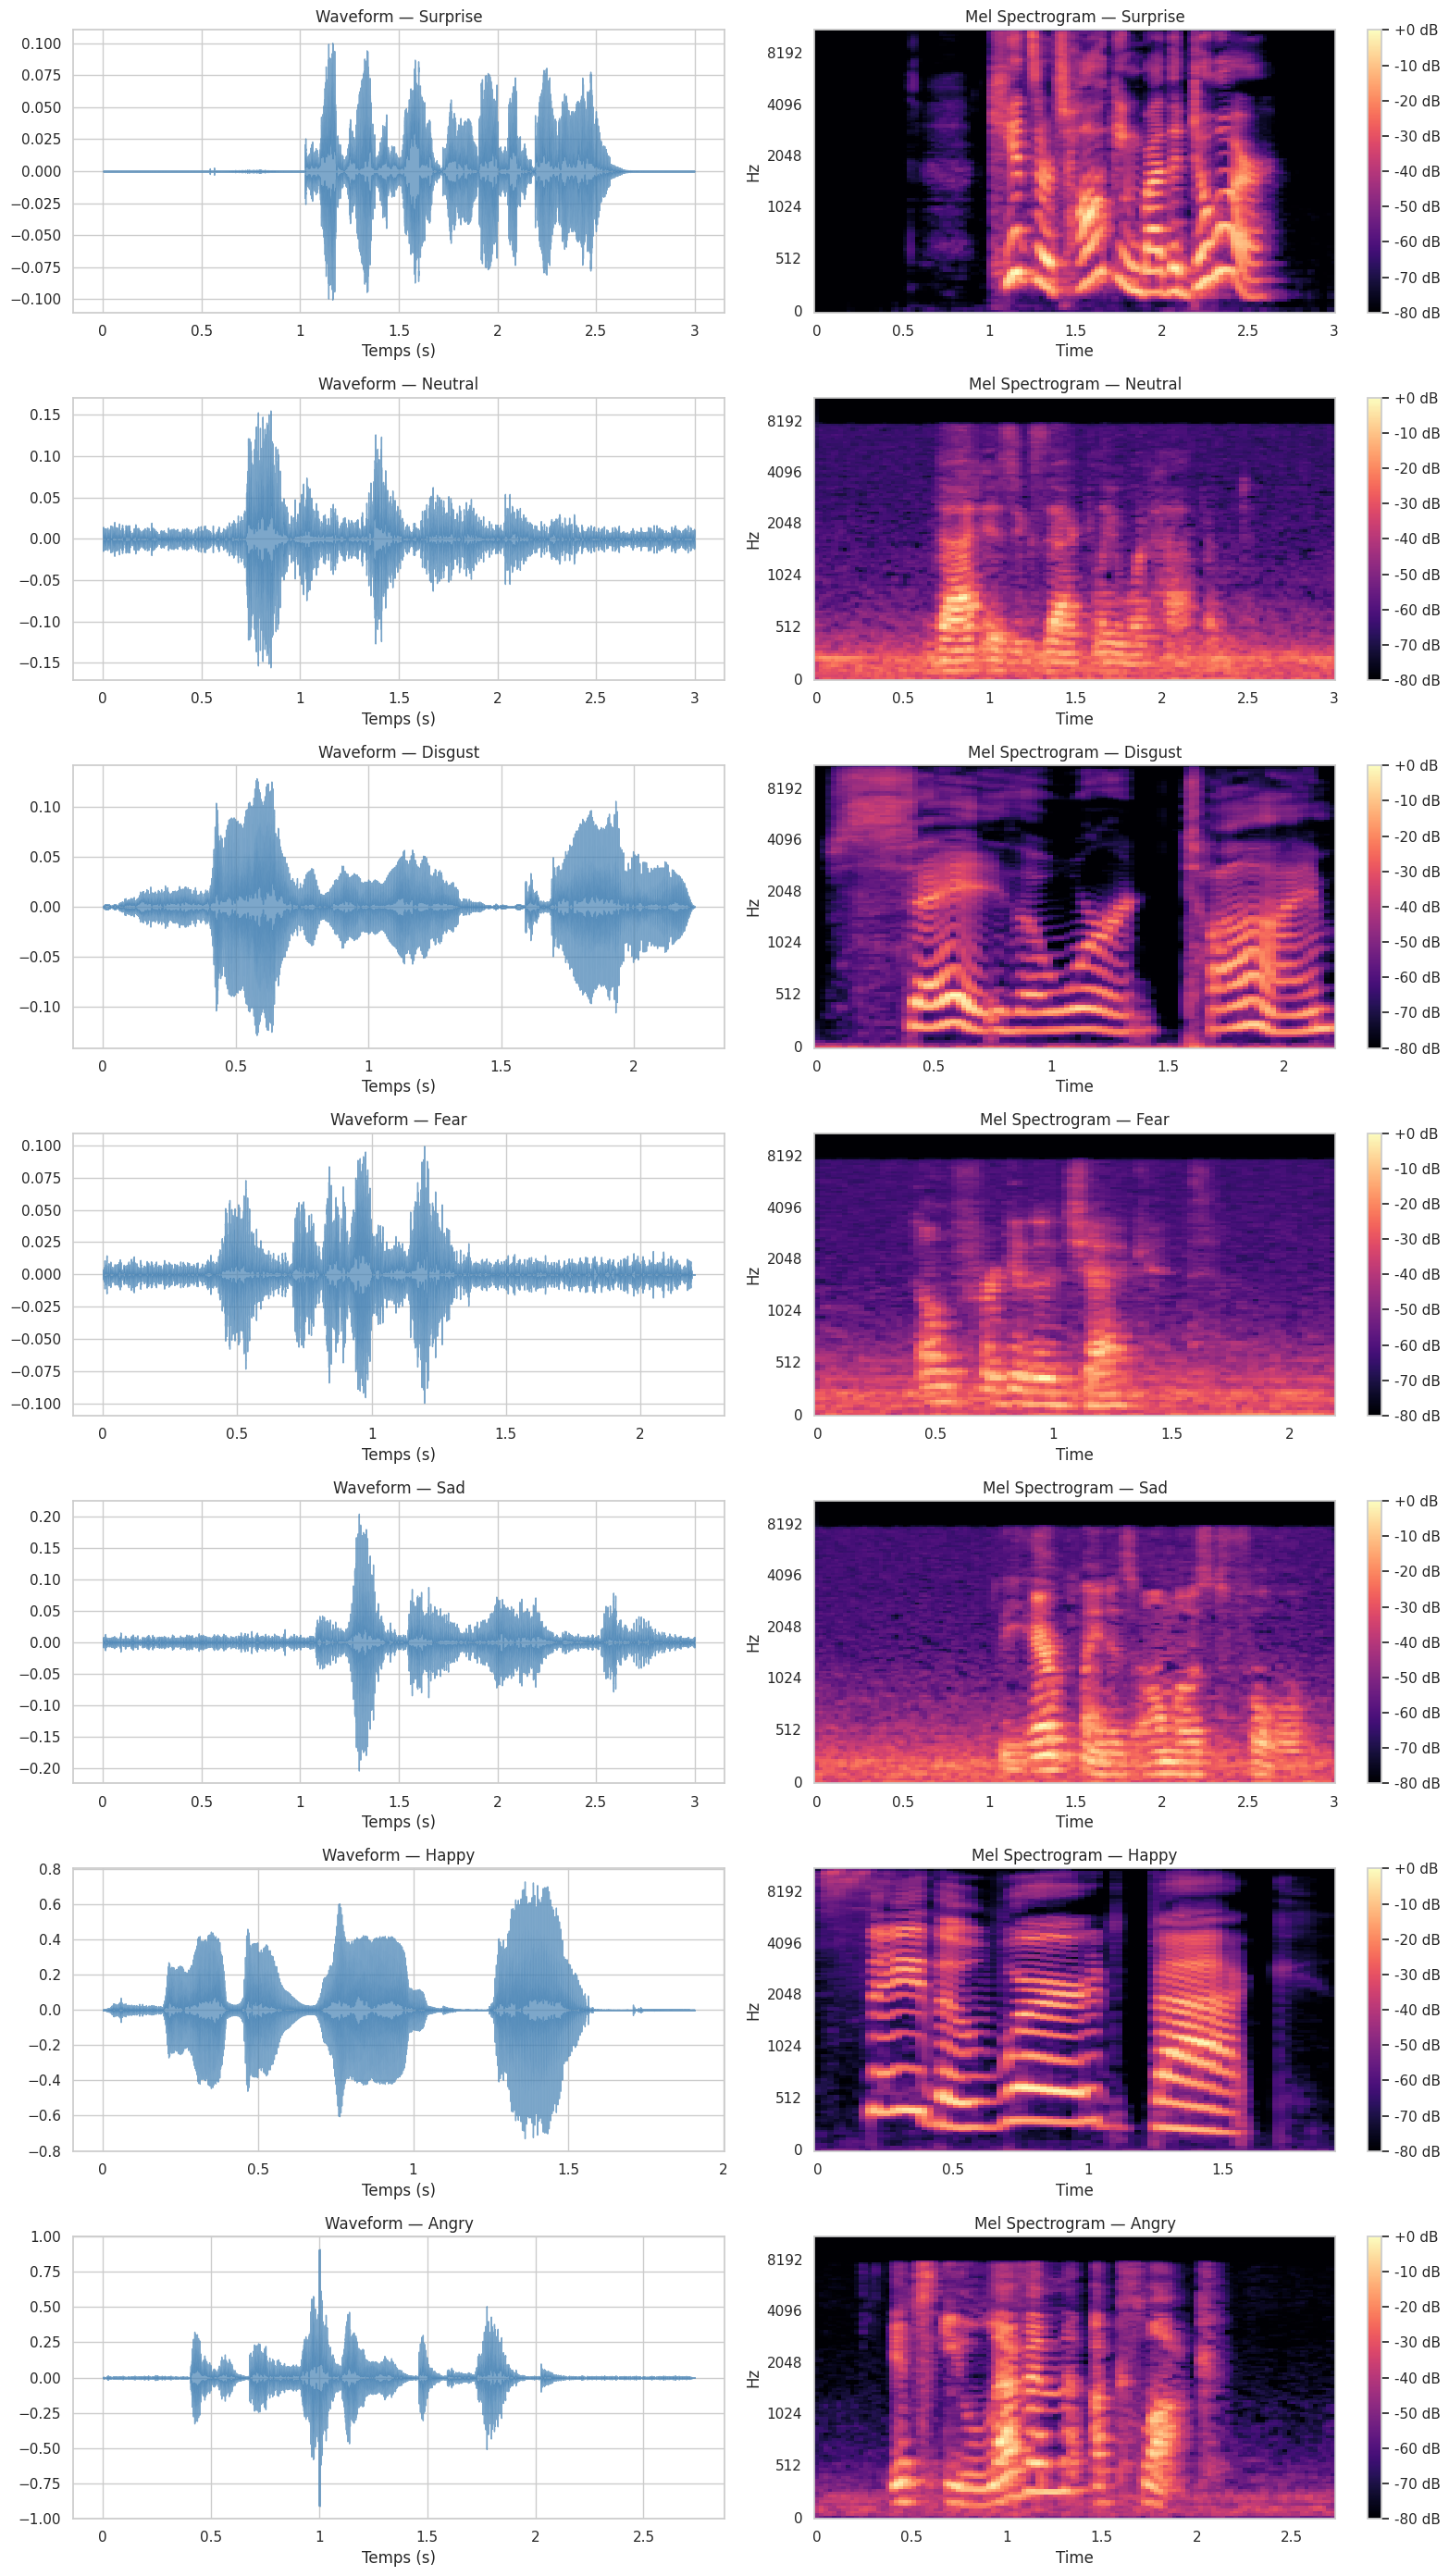


⏱️ Calcul des durées moyennes...


/tmp/ipykernel_57/3550196528.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_per_dataset = df_audio.groupby('Dataset').apply(


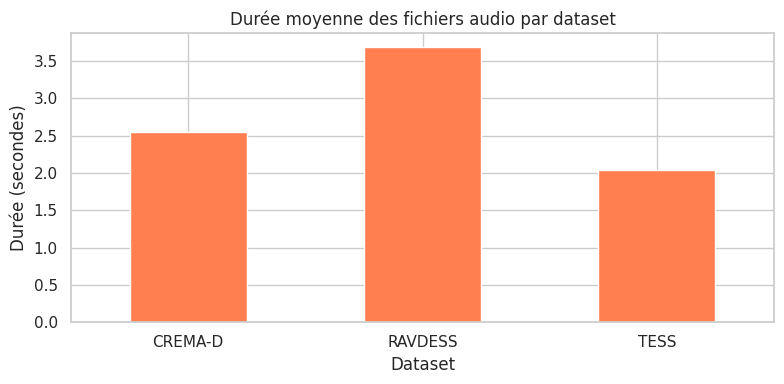

Dataset
CREMA-D    2.543475
RAVDESS    3.692357
TESS       2.034861


In [7]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

# ==========================================
# 1. DISTRIBUTION DES ÉMOTIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 — Barplot par émotion
counts = df_audio['Sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Nombre de fichiers par émotion', fontsize=14)
axes[0].set_xlabel('Émotion')
axes[0].set_ylabel('Nombre de fichiers')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Graphique 2 — Pie chart par dataset
dataset_counts = df_audio['Dataset'].value_counts()
axes[1].pie(dataset_counts.values,
            labels=dataset_counts.index,
            autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'green', 'orange'])
axes[1].set_title('Répartition par dataset', fontsize=14)

plt.tight_layout()
plt.show()

print("📊 Résumé :")
print(f"   Total fichiers    : {len(df_audio)}")
print(f"   Nombre d'émotions : {df_audio['Sentiment'].nunique()}")
print(f"   Datasets          : {list(df_audio['Dataset'].unique())}")

# ==========================================
# 2. WAVEFORM + SPECTROGRAMME PAR ÉMOTION
# ==========================================
emotions = df_audio['Sentiment'].unique()
fig, axes = plt.subplots(len(emotions), 2, figsize=(16, 4*len(emotions)))

for i, emotion in enumerate(emotions):
    # Prendre un fichier aléatoire de cette émotion
    sample = df_audio[df_audio['Sentiment'] == emotion].sample(1).iloc[0]
    y, sr = librosa.load(sample['Chemin_Absolu'], sr=22050, duration=3)

    # Waveform
    axes[i, 0].set_title(f'Waveform — {emotion}', fontsize=12)
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], alpha=0.7, color='steelblue')
    axes[i, 0].set_xlabel('Temps (s)')

    # Spectrogramme de Mel
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel',
                                    sr=sr, ax=axes[i, 1])
    axes[i, 1].set_title(f'Mel Spectrogram — {emotion}', fontsize=12)
    plt.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

# ==========================================
# 3. DURÉE MOYENNE DES FICHIERS PAR DATASET
# ==========================================
print("\n⏱️ Calcul des durées moyennes...")

durations = []
sample_per_dataset = df_audio.groupby('Dataset').apply(
    lambda x: x.sample(min(50, len(x)), random_state=42)
).reset_index(drop=True)

for _, row in sample_per_dataset.iterrows():
    try:
        duration = librosa.get_duration(path=row['Chemin_Absolu'])
        durations.append({'Dataset': row['Dataset'], 'Durée': duration})
    except:
        pass

df_durations = pd.DataFrame(durations)

plt.figure(figsize=(8, 4))
df_durations.groupby('Dataset')['Durée'].mean().plot(kind='bar',
                                                      color='coral',
                                                      edgecolor='white')
plt.title('Durée moyenne des fichiers audio par dataset')
plt.xlabel('Dataset')
plt.ylabel('Durée (secondes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df_durations.groupby('Dataset')['Durée'].mean().to_string())

## 5. Extraction des Caractéristiques (Feature Extraction)

In [8]:
import numpy as np
import librosa
import os
import gc
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# ==========================================
# CONFIGURATION
# ==========================================
SR = 22050
DURATION = 3
SAMPLES = SR * DURATION   # 66 150 échantillons
N_MELS = 128
BATCH_SIZE = 500
SAVE_DIR = '/kaggle/working/features'
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# FONCTION 1 — SPECTROGRAMME 3 CANAUX
# ==========================================
def get_spectrogram_3ch(audio):
    """
    Transforme un signal audio en image 3 canaux :
    Canal 1 → Mel Spectrogram (énergie par fréquence)
    Canal 2 → Delta          (vitesse du changement)
    Canal 3 → Delta-Delta    (accélération du changement)
    Shape finale → (128, 130, 3)
    """
    # Mel Spectrogram de base
    S    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
    logS = librosa.power_to_db(S, ref=np.max)

    # Normalisation Z-Score
    logS = (logS - np.mean(logS)) / (np.std(logS) + 1e-6)

    # Delta et Delta-Delta
    delta  = librosa.feature.delta(logS)
    delta2 = librosa.feature.delta(logS, order=2)

    # Empiler les 3 canaux → (128, 130, 3)
    return np.stack([logS, delta, delta2], axis=-1)

# ==========================================
# FONCTION 2 — AUGMENTATION AUDIO
# ==========================================
def augment_audio(audio):
    """
    Crée 3 versions modifiées de l'audio original :
    1. Noise  → ajoute du bruit de fond
    2. Pitch  → monte le ton de 2 demi-tons
    3. Stretch → accélère légèrement la voix
    """
    # Bruit gaussien
    noise = audio + 0.005 * np.random.randn(len(audio))

    # Décalage de pitch
    pitch = librosa.effects.pitch_shift(audio, sr=SR, n_steps=2)

    # Time stretch
    ts = librosa.effects.time_stretch(audio, rate=1.1)
    if len(ts) < SAMPLES:
        ts = np.pad(ts, (0, SAMPLES - len(ts)), 'constant')
    else:
        ts = ts[:SAMPLES]

    return [noise, pitch, ts]

# ==========================================
# FONCTION 3 — SPEC AUGMENT
# ==========================================
def apply_spec_augment(spec, num_mask=2, freq_mask=15, time_mask=20):
    """
    Masque aléatoirement des bandes de fréquence et de temps
    pour forcer le modèle à ne pas surappendre
    """
    aug = spec.copy()
    n_mels, n_steps, _ = aug.shape
    for _ in range(num_mask):
        # Masque fréquentiel
        f  = np.random.randint(0, freq_mask)
        f0 = np.random.randint(0, n_mels - f)
        aug[f0:f0+f, :, :] = 0
        # Masque temporel
        t  = np.random.randint(0, time_mask)
        t0 = np.random.randint(0, n_steps - t)
        aug[:, t0:t0+t, :] = 0
    return aug

# ==========================================
# FONCTION 4 — TRAITEMENT D'UN FICHIER
# ==========================================
def process_single_file(row_tuple):
    """
    Pour chaque fichier audio → génère 8 exemples :
    Original + 3 augmentations audio = 4 versions
    Chaque version × 2 (normale + SpecAugment) = 8 exemples
    """
    _, row = row_tuple
    path  = row['Chemin_Absolu']
    label = row['Numero_Sentiment']
    local_X, local_y = [], []

    try:
        # Chargement + suppression des silences
        y, _ = librosa.load(path, sr=SR, duration=DURATION)
        y, _ = librosa.effects.trim(y, top_db=20)

        # Normaliser la durée
        if len(y) < SAMPLES:
            y = np.pad(y, (0, SAMPLES - len(y)), 'constant')
        else:
            y = y[:SAMPLES]

        # 4 versions audio : original + 3 augmentations
        all_audios = [y] + augment_audio(y)

        for signal in all_audios:
            # Extraire spectrogramme 3 canaux
            feat = get_spectrogram_3ch(signal)

            # Version normale
            local_X.append(feat)
            local_y.append(label)

            # Version SpecAugment
            local_X.append(apply_spec_augment(feat))
            local_y.append(label)

        return local_X, local_y

    except Exception:
        return None

# ==========================================
# EXTRACTION PAR LOTS
# ==========================================
def run_extraction(df):
    all_rows   = list(df.iterrows())
    total      = len(all_rows)
    n_batches  = (total + BATCH_SIZE - 1) // BATCH_SIZE
    total_saved = 0

    print(f"📦 {total} fichiers → {n_batches} lots de {BATCH_SIZE}")
    print(f"📐 Chaque fichier génère 8 exemples")
    print(f"🔢 Total attendu : ~{total * 8} exemples\n")

    for i in tqdm(range(0, total, BATCH_SIZE), desc="Extraction"):
        batch_idx = i // BATCH_SIZE
        chunk     = all_rows[i : i + BATCH_SIZE]

        X_batch, y_batch = [], []

        with ProcessPoolExecutor() as executor:
            results = list(executor.map(process_single_file, chunk))

        for res in results:
            if res is not None:
                X_b, y_b = res
                X_batch.extend(X_b)
                y_batch.extend(y_b)

        if X_batch:
            X_np = np.array(X_batch, dtype='float32')
            y_np = np.array(y_batch)

            # Afficher la shape du premier lot
            if batch_idx == 0:
                print(f"\n📐 Shape d'un lot : {X_np.shape}")
                print(f"   → {X_np.shape[0]} exemples")
                print(f"   → {X_np.shape[1]}×{X_np.shape[2]} pixels")
                print(f"   → {X_np.shape[3]} canaux\n")

            # Sauvegarde
            path = os.path.join(SAVE_DIR, f"batch_{batch_idx}.npz")
            np.savez_compressed(path, X=X_np, y=y_np)
            total_saved += len(X_np)

            # Libérer la RAM
            del X_batch, y_batch, X_np, y_np, results
            gc.collect()

    print(f"\n{'='*40}")
    print(f"✅ EXTRACTION TERMINÉE")
    print(f"📁 Sauvegardé dans : {SAVE_DIR}")
    print(f"🔢 Total exemples  : {total_saved}")
    print(f"{'='*40}")

# ==========================================
# LANCEMENT
# ==========================================
run_extraction(df_audio)

📦 15538 fichiers → 32 lots de 500
📐 Chaque fichier génère 8 exemples
🔢 Total attendu : ~124304 exemples



Extraction:   0%|          | 0/32 [00:00<?, ?it/s]


📐 Shape d'un lot : (4000, 128, 130, 3)
   → 4000 exemples
   → 128×130 pixels
   → 3 canaux



Extraction: 100%|██████████| 32/32 [51:05<00:00, 95.81s/it] 


✅ EXTRACTION TERMINÉE
📁 Sauvegardé dans : /kaggle/working/features
🔢 Total exemples  : 124304


## 6. Construction et Entraînement du Modèle CNN-LSTM

In [9]:
import tensorflow as tf
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import optimizers, callbacks
from tensorflow.keras.utils import Sequence, to_categorical

# ==========================================
# CONFIGURATION
# ==========================================
SAVE_DIR    = '/kaggle/working/features'
TFRECORD_DIR = '/kaggle/working/tfrecords'
os.makedirs(TFRECORD_DIR, exist_ok=True)

SHAPE       = (128, 130, 3)
NUM_CLASSES = 7
BATCH_SIZE  = 128

# ==========================================
# ÉTAPE 1 — NPZ → TFRECORDS
# ==========================================
def serialize_example(x, y):
    feature = {
        'x': tf.train.Feature(bytes_list=tf.train.BytesList(value=[x.tobytes()])),
        'y': tf.train.Feature(int64_list=tf.train.Int64List(value=[y])),
    }
    return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()

npz_files = sorted(glob.glob(os.path.join(SAVE_DIR, "*.npz")))
print(f"📦 Conversion de {len(npz_files)} fichiers .npz → TFRecords...")

for i, f in enumerate(npz_files):
    print(f"   {i+1}/{len(npz_files)} : {os.path.basename(f)}")
    data = np.load(f)
    X, y = data['X'], data['y']

    tfrecord_path = os.path.join(TFRECORD_DIR, f"batch_{i}.tfrecord")
    with tf.io.TFRecordWriter(tfrecord_path) as writer:
        for j in range(len(X)):
            writer.write(serialize_example(X[j], y[j]))

print("✅ Conversion terminée !")

# ==========================================
# ÉTAPE 2 — PIPELINE TF.DATA
# ==========================================
def parse_tfrecord(example):
    features = tf.io.parse_single_example(example, {
        'x': tf.io.FixedLenFeature([], tf.string),
        'y': tf.io.FixedLenFeature([], tf.int64),
    })
    x = tf.io.decode_raw(features['x'], tf.float32)
    x = tf.reshape(x, SHAPE)
    y = tf.one_hot(features['y'], depth=NUM_CLASSES)
    return x, y

# Split train / val / test
all_tfrecords = sorted(glob.glob(os.path.join(TFRECORD_DIR, "*.tfrecord")))
train_files, temp_files = train_test_split(all_tfrecords, test_size=0.2, random_state=42)
val_files,   test_files = train_test_split(temp_files,    test_size=0.5, random_state=42)

print(f"\n📊 Split :")
print(f"   Train : {len(train_files)} fichiers")
print(f"   Val   : {len(val_files)} fichiers")
print(f"   Test  : {len(test_files)} fichiers")

# Pipeline train
train_ds = tf.data.TFRecordDataset(train_files, num_parallel_reads=tf.data.AUTOTUNE)
train_ds = train_ds.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Pipeline val
val_ds = tf.data.TFRecordDataset(val_files, num_parallel_reads=tf.data.AUTOTUNE)
val_ds = val_ds.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Pipeline test
test_ds = tf.data.TFRecordDataset(test_files, num_parallel_reads=tf.data.AUTOTUNE)
test_ds = test_ds.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Pipelines tf.data prêts !")

# ==========================================
# ÉTAPE 3 — MODÈLE + COMPILATION
# ==========================================
model = build_hybrid_model(input_shape=SHAPE, num_classes=NUM_CLASSES)
model.summary()

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# ÉTAPE 4 — CALLBACKS
# ==========================================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

rlrp = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    '/kaggle/working/cnn_lstm_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# ==========================================
# ÉTAPE 5 — ENTRAÎNEMENT
# ==========================================
print("\n🏁 Entraînement lancé...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop, rlrp, checkpoint],
    verbose=1
)

# ==========================================
# ÉTAPE 6 — ÉVALUATION
# ==========================================
loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\n📊 Résultats sur le jeu de test :")
print(f"   Loss     : {loss:.4f}")
print(f"   Accuracy : {acc*100:.2f}%")

# ==========================================
# ÉTAPE 7 — COURBES + MATRICE DE CONFUSION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='coral')
axes[0].set_title('Accuracy par époque')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='coral')
axes[1].set_title('Loss par époque')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

# Matrice de confusion
emotions   = ['Neutral', 'Happy', 'Sad', 'Angry', 'Fear', 'Disgust', 'Surprise']
Y_pred, Y_true = [], []
for X_batch, y_batch in test_ds:
    preds = model.predict(X_batch, verbose=0)
    Y_pred.extend(np.argmax(preds,   axis=1))
    Y_true.extend(np.argmax(y_batch.numpy(), axis=1))

print("\n📋 Rapport de classification :")
print(classification_report(Y_true, Y_pred, target_names=emotions))

cm = confusion_matrix(Y_true, Y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=emotions, yticklabels=emotions)
plt.title('Matrice de Confusion — CNN-LSTM')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.tight_layout()
plt.show()

# ==========================================
# ÉTAPE 8 — SAUVEGARDE
# ==========================================
model.save('/kaggle/working/cnn_lstm_final.h5')
print("✅ Modèle sauvegardé : /kaggle/working/cnn_lstm_final.h5")

📦 Conversion de 32 fichiers .npz → TFRecords...
   1/32 : batch_0.npz
   2/32 : batch_1.npz
   3/32 : batch_10.npz
   4/32 : batch_11.npz
   5/32 : batch_12.npz
   6/32 : batch_13.npz
   7/32 : batch_14.npz
   8/32 : batch_15.npz
   9/32 : batch_16.npz


ResourceExhaustedError: /kaggle/working/tfrecords/batch_8.tfrecord; No space left on device

## 7. Évaluation des Performances

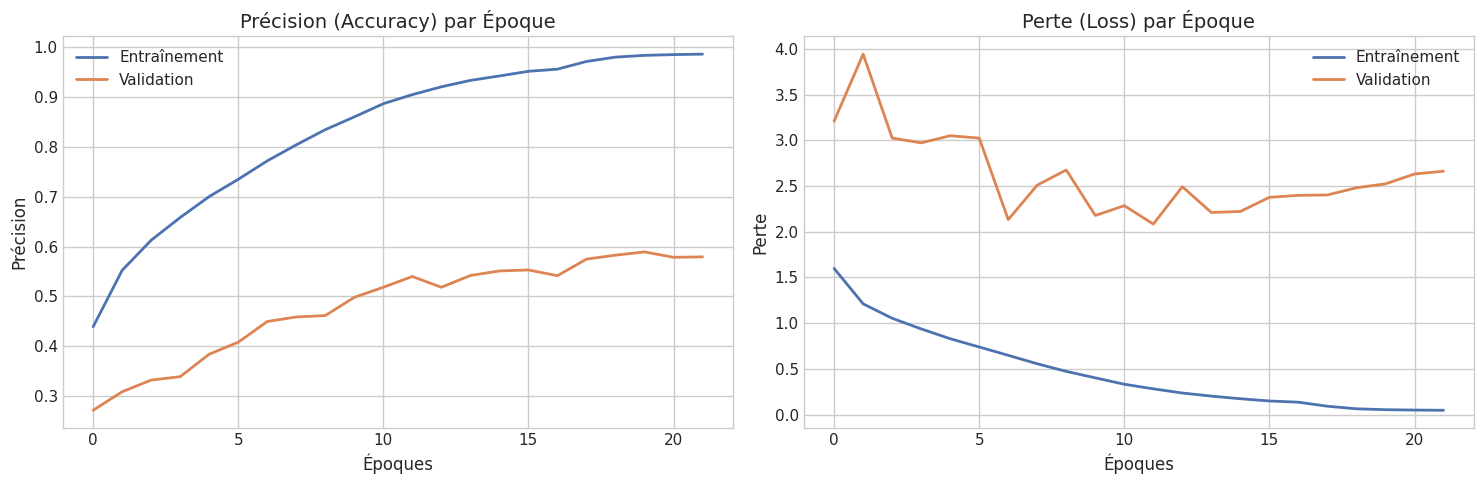

Évaluation du modèle sur les données de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.5400 - loss: 2.0838

 Précision finale : 54.00%
 Perte finale : 2.0838


I0000 00:00:1775756126.877523   23584 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6199317923713133389
I0000 00:00:1775756126.877652   23584 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14242455076103781239
I0000 00:00:1775756126.877695   23584 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13810157297392452816
/home/reda-alilou/audio-project/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [18]:
import matplotlib.pyplot as plt

def plot_history(history):
    # Utilisation d'un style plus propre pour les rapports
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(15, 5))

    # 1. Graphique de l'Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entraînement', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    plt.title('Précision (Accuracy) par Époque', fontsize=14)
    plt.xlabel('Époques')
    plt.ylabel('Précision')
    plt.legend()

    # 2. Graphique de la Perte (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entraînement', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
    plt.title('Perte (Loss) par Époque', fontsize=14)
    plt.xlabel('Époques')
    plt.ylabel('Perte')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Affichage des courbes
plot_history(history)

# --- CORRECTION DE L'ÉVALUATION ---
# On utilise val_gen car X_test n'est pas chargé en RAM
print("Évaluation du modèle sur les données de validation...")
test_loss, test_acc = model.evaluate(val_ds, verbose=1)

print(f"\n" + "="*30)
print(f" Précision finale : {test_acc*100:.2f}%")
print(f" Perte finale : {test_loss:.4f}")
print("="*30)

Calcul des prédictions sur l'ensemble de validation...


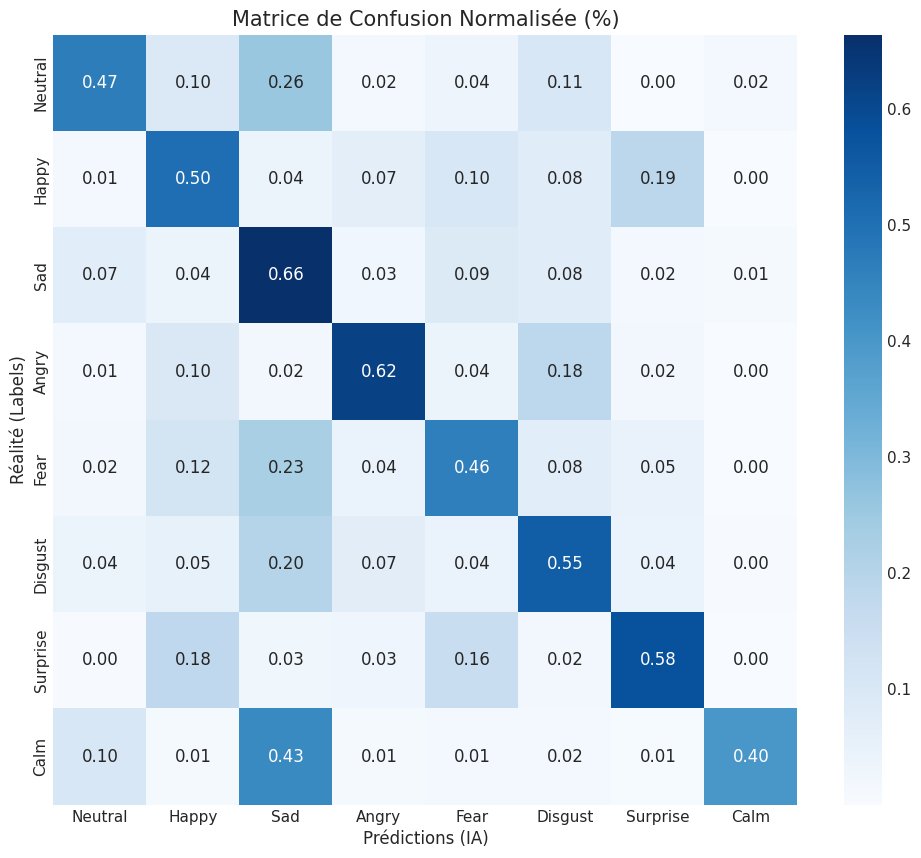


--- Rapport de Classification Détaillé ---
              precision    recall  f1-score   support

     Neutral       0.69      0.47      0.56      2592
       Happy       0.63      0.50      0.56      4408
         Sad       0.44      0.66      0.53      2808
       Angry       0.70      0.62      0.66      2968
        Fear       0.53      0.46      0.49      2856
     Disgust       0.50      0.55      0.52      2936
    Surprise       0.30      0.58      0.39       888
        Calm       0.69      0.40      0.51       544

    accuracy                           0.54     20000
   macro avg       0.56      0.53      0.53     20000
weighted avg       0.57      0.54      0.55     20000



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("Calcul des prédictions sur l'ensemble de validation...")

y_true = []
y_pred = []

for X_batch, y_batch in val_ds:
    preds = model.predict(X_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels_emotions = [k for k, v in sorted(emotion_map_str_to_int.items(), key=lambda item: item[1])]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_emotions, yticklabels=labels_emotions)
plt.xlabel('Prédictions (IA)', fontsize=12)
plt.ylabel('Réalité (Labels)', fontsize=12)
plt.title('Matrice de Confusion Normalisée (%)', fontsize=15)
plt.show()

print("\n--- Rapport de Classification Détaillé ---")
print(classification_report(y_true, y_pred, target_names=labels_emotions))

In [20]:
model.save(os.path.expanduser("~/audio-project/base_model_english.keras"))

In [21]:
import pickle

MODEL_SAVE_PATH = os.path.expanduser("~/audio-project/base_model_english.keras")
print(f"Model saved at: {MODEL_SAVE_PATH}")

history_path = os.path.expanduser("~/audio-project/training_history.pkl")
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)
print("Training history saved.")

Model saved at: /home/reda-alilou/audio-project/base_model_english.keras
Training history saved.


## 8. Fine-tuning Wav2Vec2 pour la Classification des Émotions

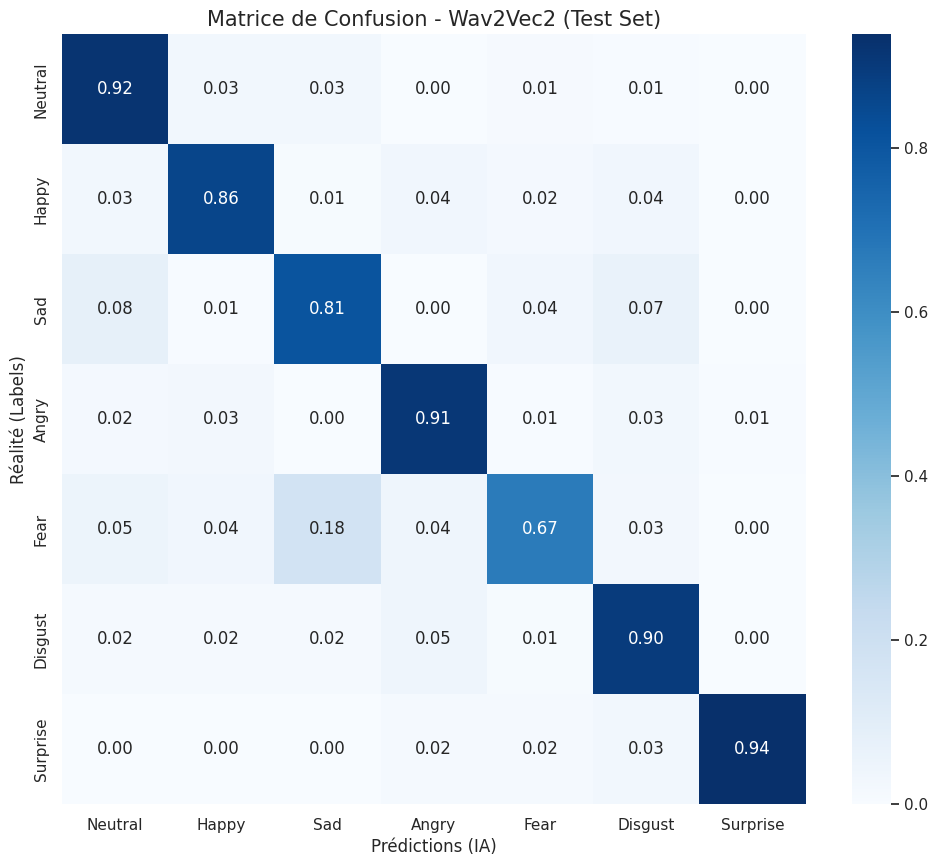

              precision    recall  f1-score   support

     Neutral       0.80      0.92      0.86       170
       Happy       0.89      0.86      0.88       192
         Sad       0.78      0.81      0.79       193
       Angry       0.88      0.91      0.89       192
        Fear       0.88      0.67      0.76       193
     Disgust       0.83      0.90      0.86       192
    Surprise       0.98      0.94      0.96        65

    accuracy                           0.85      1197
   macro avg       0.86      0.86      0.86      1197
weighted avg       0.85      0.85      0.85      1197



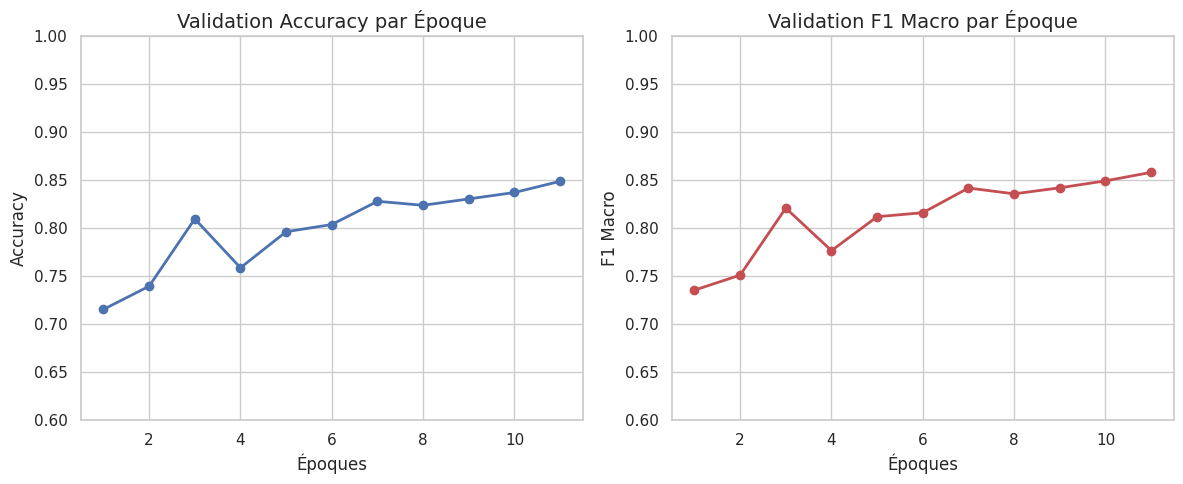


Test Accuracy: 84.88%
Test F1 Macro: 85.81%


In [6]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load results from the training script
with open(os.path.expanduser("~/audio-project/wav2vec2-results/results.pkl"), 'rb') as f:
    results = pickle.load(f)

y_true = results['y_true']
y_pred = results['y_pred']
labels = results['labels']
cm = results['confusion_matrix']

# 1. Confusion Matrix
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prédictions (IA)', fontsize=12)
plt.ylabel('Réalité (Labels)', fontsize=12)
plt.title('Matrice de Confusion - Wav2Vec2 (Test Set)', fontsize=15)
plt.show()

# 2. Classification Report
print(results['classification_report'])

# 3. Training curves
history = results['train_history']
eval_entries = [h for h in history if 'eval_f1_macro' in h]
epochs = list(range(1, len(eval_entries) + 1))
f1_scores = [h['eval_f1_macro'] for h in eval_entries]
accuracies = [h['eval_accuracy'] for h in eval_entries]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracies, 'b-o', linewidth=2)
plt.title('Validation Accuracy par Époque', fontsize=14)
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0)

plt.subplot(1, 2, 2)
plt.plot(epochs, f1_scores, 'r-o', linewidth=2)
plt.title('Validation F1 Macro par Époque', fontsize=14)
plt.xlabel('Époques')
plt.ylabel('F1 Macro')
plt.ylim(0.6, 1.0)

plt.tight_layout()
plt.show()

print(f"\nTest Accuracy: {results['test_results']['eval_accuracy']*100:.2f}%")
print(f"Test F1 Macro: {results['test_results']['eval_f1_macro']*100:.2f}%")

In [7]:
import mlflow
import mlflow.pytorch
import pickle
import os

# Load results
with open(os.path.expanduser("~/audio-project/wav2vec2-results/results.pkl"), 'rb') as f:
    results = pickle.load(f)

# Start MLflow run
mlflow.set_experiment("Speech_Emotion_Recognition")

with mlflow.start_run(run_name="Wav2Vec2_7classes"):
    # Log parameters
    mlflow.log_param("model", "facebook/wav2vec2-base")
    mlflow.log_param("num_classes", 7)
    mlflow.log_param("epochs", 10)
    mlflow.log_param("batch_size", 4)
    mlflow.log_param("gradient_accumulation_steps", 4)
    mlflow.log_param("learning_rate", 1e-4)
    mlflow.log_param("max_audio_length_sec", 3)
    mlflow.log_param("sample_rate", 16000)
    mlflow.log_param("fp16", True)
    
    # Log final test metrics
    mlflow.log_metric("test_accuracy", results['test_results']['eval_accuracy'])
    mlflow.log_metric("test_f1_macro", results['test_results']['eval_f1_macro'])
    mlflow.log_metric("test_loss", results['test_results']['eval_loss'])
    
    # Log per-epoch metrics
    eval_entries = [h for h in results['train_history'] if 'eval_f1_macro' in h]
    for i, entry in enumerate(eval_entries):
        mlflow.log_metric("val_accuracy", entry['eval_accuracy'], step=i+1)
        mlflow.log_metric("val_f1_macro", entry['eval_f1_macro'], step=i+1)
        mlflow.log_metric("val_loss", entry['eval_loss'], step=i+1)
    
    # Log classification report as artifact
    report_path = os.path.expanduser("~/audio-project/classification_report.txt")
    with open(report_path, 'w') as f:
        f.write(results['classification_report'])
    mlflow.log_artifact(report_path)
    
    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print("Logged to MLflow!")

# Show the UI
print("\nTo view the dashboard, run in terminal:")
print("  cd ~/audio-project && mlflow ui")
print("  Then open http://127.0.0.1:5000")

/home/reda-alilou/audio-project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/04/09 21:00:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/09 21:00:01 INFO mlflow.store.db.utils: Updating database tables
2026/04/09 21:00:02 INFO mlflow.tracking.fluent: Experiment with name 'Speech_Emotion_Recognition' does not exist. Creating a new experiment.


Run ID: 03e20f789be14e27838d079b9c07af23
Logged to MLflow!

To view the dashboard, run in terminal:
  cd ~/audio-project && mlflow ui
  Then open http://127.0.0.1:5000
